# Test Define-by-Run

Add patches during circuit construction. Flow:
1. Add patch_1 (UnrotatedSurfaceCode d=3), setup tracker+builder, register tracker
2. Init patch_1, d rounds SE
3. Add patch_2 (define-by-run) -> tracker auto-expands
4. init patch_2, reorder tracker, d rounds SE for patch_2 only (expected_num_logicals auto-synced by add_patch)
5. Final measure in same basis as init

In [1]:
import sys
from pathlib import Path

ROOT = Path('../..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import stim

from lightstim.ir.qec_system import QECSystem
from lightstim.ir.builder import CircuitBuilder
from lightstim.ir.tracker import SyndromeTracker
from lightstim.qec_code.surface_code.unrotated import (
    UnrotatedSurfaceCode,
    UnrotatedSurfaceCodeExtractionBlock,
)
from lightstim.qec_code.surface_code.rotated import (
    RotatedSurfaceCode,
    RotatedSurfaceCodeExtractionBlock,
)
from lightstim.qec_code.repetition import RepetitionCode, RepetitionCodeExtractionBlock

# Code registry: code_name -> (PatchClass, SEBlockClass)
CODE_REGISTRY = {
    "unrotated": (UnrotatedSurfaceCode, UnrotatedSurfaceCodeExtractionBlock),
    "rotated": (RotatedSurfaceCode, RotatedSurfaceCodeExtractionBlock),
    "repetition": (RepetitionCode, RepetitionCodeExtractionBlock),
}


def _reorder_tracker_for_patch_se(tracker, n_patch_rows: int):
    """Put patch's rows (last n_patch_rows) first so anti-commute pivots hit them."""
    n = tracker.stabilizers.count
    if n_patch_rows >= n:
        return
    perm = list(range(n - n_patch_rows, n)) + list(range(n - n_patch_rows))
    tracker.stabilizers.matrix = tracker.stabilizers.matrix[perm]
    tracker.stabilizers.records = [tracker.stabilizers.records[i] for i in perm]


## Sequence Memory Experiment

General experiment: given a sequence of (code_type, params), add patches to the system one by one (define-by-run), run SE for each, and final measure. Tests time-stitching of Memory Experiment.

In [2]:
class SequenceMemoryExperiment:
    """
    Memory Experiment for a sequence of QEC patches (define-by-run).
    Given a sequence of (code_type, params), adds patches one by one,
    runs SE for each, and final measures all data qubits.
    Tests time-stitching of Memory Experiment for define-by-run validation.
    """
    def __init__(self,
                 sequence: list,
                 rounds: int = 3,
                 basis: str = "Z",
                 if_detector: bool = True,
                 offsets: list = None):
        """
        Args:
            sequence: List of dicts, e.g. [{"code": "unrotated", "distance": 3}, ...]
                      Max length 3. code in {"unrotated", "rotated", "repetition"}.
            rounds: SE rounds per patch.
            basis: Memory basis ('X' or 'Z').
            if_detector: Whether to generate detectors.
            offsets: Optional list of (dx, dy) per patch. Default: auto-spaced.
        """
        if len(sequence) > 3:
            raise ValueError("Sequence length max 3.")
        self.sequence = sequence
        self.rounds = rounds
        self.basis = basis.upper()
        self.if_detector = if_detector
        self.offsets = offsets or self._default_offsets()
        self.system = None
        self.tracker = None
        self.builder = None

    def _default_offsets(self):
        """Space patches along x: (0,0), (8,0), (16,0)."""
        return [(8 * i, 0) for i in range(len(self.sequence))]

    def build(self) -> stim.Circuit:
        system = QECSystem()
        # First patch
        spec = self.sequence[0]
        PatchCls, _ = CODE_REGISTRY[spec["code"]]
        params = {k: v for k, v in spec.items() if k != "code"}
        patch = PatchCls(**params)
        system.add_patch(patch, offset=self.offsets[0], name="patch_0", is_active=True)

        tracker = SyndromeTracker(
            num_qubits=system.num_qubits,
            expected_num_logicals=system.num_logicals,
        )
        builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=self.if_detector)
        system.register_tracker(tracker)
        system.register_builder(builder)

        builder.write_coordinates()
        n = system.num_qubits
        data = list(system.data_indices)
        builder.initialize(init_dict={q: self.basis for q in data}, n=n)

        _, SEBlockCls = CODE_REGISTRY[spec["code"]]
        builder.apply_syndrome_extraction(SEBlockCls(system).circuit, rounds=self.rounds)

        # Remaining patches (define-by-run)
        for i, spec in enumerate(self.sequence[1:], start=1):
            PatchCls, SEBlockCls = CODE_REGISTRY[spec["code"]]
            params = {k: v for k, v in spec.items() if k != "code"}
            system.add_patch(PatchCls(**params), offset=self.offsets[i], name=f"patch_{i}", is_active=True)
            patch = system.patches[f"patch_{i}"][0]
            data_i = [system.local_to_global_map[f"patch_{i}"][j] for j in patch.data_indices]
            builder.initialize(init_dict={q: self.basis for q in data_i}, n=system.num_qubits)
            system.active_stabilizer_indices = {
                idx for idx, s in enumerate(system.stabilizers)
                if s.get("patch_name") == f"patch_{i}"
            }
            builder.apply_syndrome_extraction(SEBlockCls(system).circuit, rounds=self.rounds)

        # Final readout
        final_measurements = {q: self.basis for q in system.data_indices}
        builder.apply_data_readout(final_measurements=final_measurements)

        self.system = system
        self.tracker = tracker
        self.builder = builder
        return builder.circuit

### Test: sequence length 1 (single patch)

In [3]:
seq1 = [{"code": "unrotated", "distance": 3}]
exp1 = SequenceMemoryExperiment(sequence=seq1, rounds=1, basis="X")
circ1 = exp1.build()
print(f"Seq len 1: num_qubits={exp1.system.num_qubits}, detectors={circ1.num_detectors}, observables={circ1.num_observables}")
# circ1.diagram("detslice-with-ops-svg")

Seq len 1: num_qubits=25, detectors=12, observables=1


### Test: sequence length 2

Seq len 2: num_qubits=42, detectors=20, observables=2


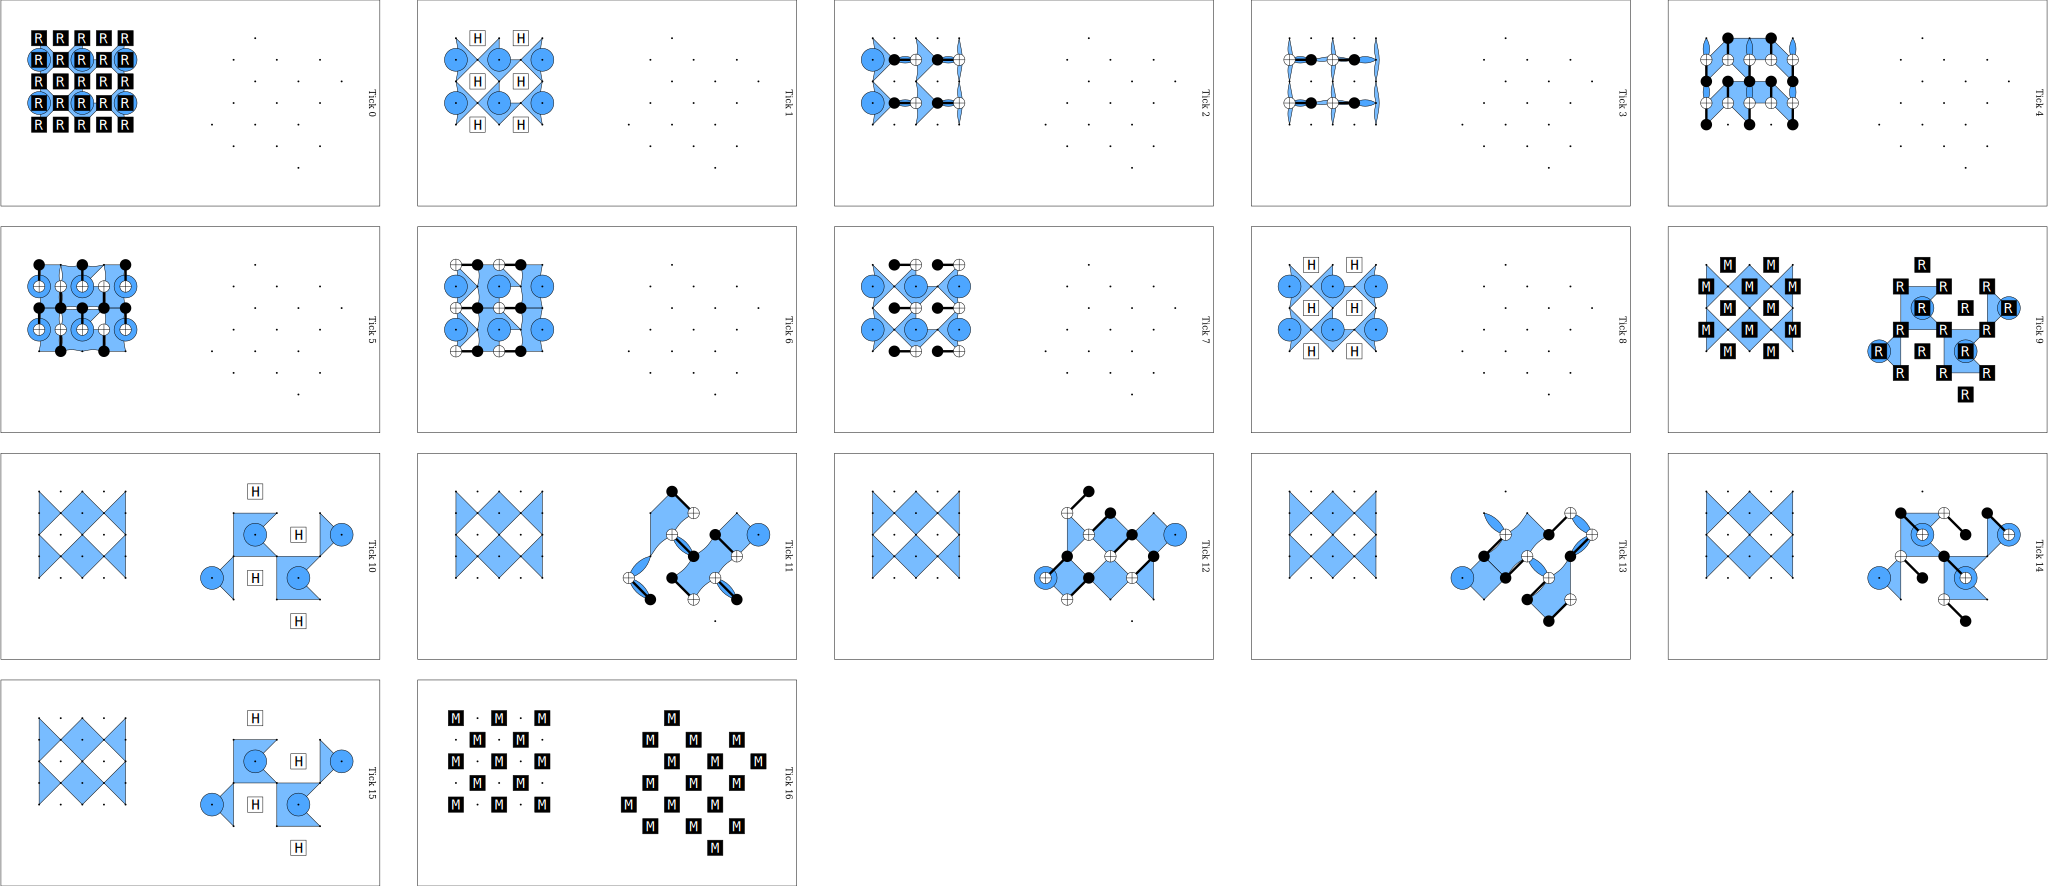

In [4]:
seq2 = [
    {"code": "unrotated", "distance": 3},
    {"code": "rotated", "distance": 3},
]
exp2 = SequenceMemoryExperiment(sequence=seq2, rounds=1, basis="Z")
circ2 = exp2.build()
print(f"Seq len 2: num_qubits={exp2.system.num_qubits}, detectors={circ2.num_detectors}, observables={circ2.num_observables}")
circ2.diagram("detslice-with-ops-svg")

### Test: sequence length 3

Seq len 3: num_qubits=51, detectors=20, observables=3


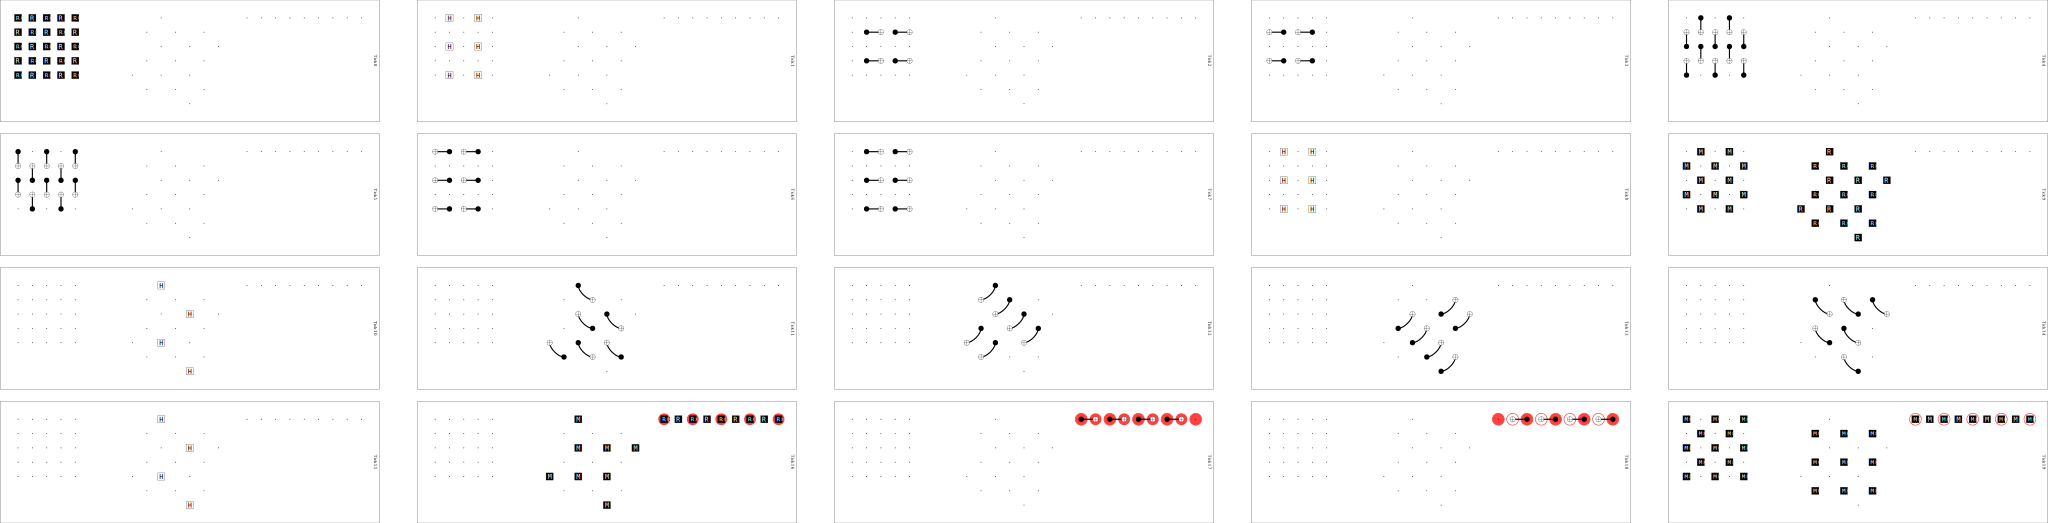

In [5]:
seq3 = [
    {"code": "unrotated", "distance": 3},
    {"code": "rotated", "distance": 3},
    {"code": "repetition", "distance": 5},
]
exp3 = SequenceMemoryExperiment(sequence=seq3, rounds=1, basis="X")
circ3 = exp3.build()
print(f"Seq len 3: num_qubits={exp3.system.num_qubits}, detectors={circ3.num_detectors}, observables={circ3.num_observables}")
# circ3.diagram("detslice-with-ops-svg")
circ3.diagram("detslice-with-ops-svg", filter_coords=["L2"]) # try L0, L1